# Chapter 144 — Vectors in Physics

> **Prerequisites:** ch125 (Vector Addition), ch126 (Scalar Multiplication), ch128 (Norm), ch130 (Direction Vectors), ch133 (Angles Between Vectors)  
> **You will learn:**
> - How physical quantities — force, velocity, acceleration — are vectors
> - Newton's second law and superposition as vector operations
> - Work, power, and torque via dot and cross products
> - How to simulate basic Newtonian mechanics with vectors in code
> - Why physical intuition about vectors transfers directly to data science
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Physics was the original motivation for vectors. Quantities like force, velocity, and acceleration cannot be fully described by a single number — they have both magnitude and direction. Vectors provide the natural language.

**Scalar vs vector quantities:**
- **Scalars:** mass (kg), temperature (°C), speed (m/s), energy (J) — magnitude only
- **Vectors:** force (N), velocity (m/s with direction), acceleration (m/s²), displacement (m), torque (N·m)

**Why this chapter matters beyond physics:** The structures here — superposition, work as a dot product, torque as a cross product — are templates that reappear throughout data science and ML. Gradient descent is an application of force-like vectors. Attention mechanisms compute scaled dot products. The physics intuition makes the math visceral.

**Common misconception:** "Physics vectors are different from math vectors." They are the same object. A force vector **F** ∈ ℝ³ satisfies all eight axioms from ch137. The physics gives intuition; the math gives precision.

---

## 2. Intuition & Mental Models

**Superposition = vector addition:** Multiple forces acting on an object combine by vector addition. The net force is the vector sum. This is why vector addition *(introduced in ch125)* has the tip-to-tail interpretation — it models what forces physically do.

**Work = dot product:** When you push an object with force **F** through displacement **d**, only the component of force *along* the direction of motion does useful work. Work = **F** · **d** = ‖**F**‖‖**d**‖cos θ. *(The projection formula from ch134 makes this concrete: work is the projection of force onto displacement, scaled by displacement magnitude.)*

**Torque = cross product:** The rotational effect of a force depends on both the force magnitude and how far from the pivot it acts. Torque **τ** = **r** × **F** is a cross product *(introduced in ch136)* — its magnitude is the "turning power," its direction gives the axis of rotation.

**Computational model:** In a physics simulation, every object has state vectors: position **x** ∈ ℝ³, velocity **v** ∈ ℝ³, acceleration **a** ∈ ℝ³. Each timestep: **v** ← **v** + **a**·Δt, **x** ← **x** + **v**·Δt. This is Euler integration — a purely vector operation.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_22552\880027452.py:65: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22552\880027452.py:65: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22552\880027452.py:65: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning

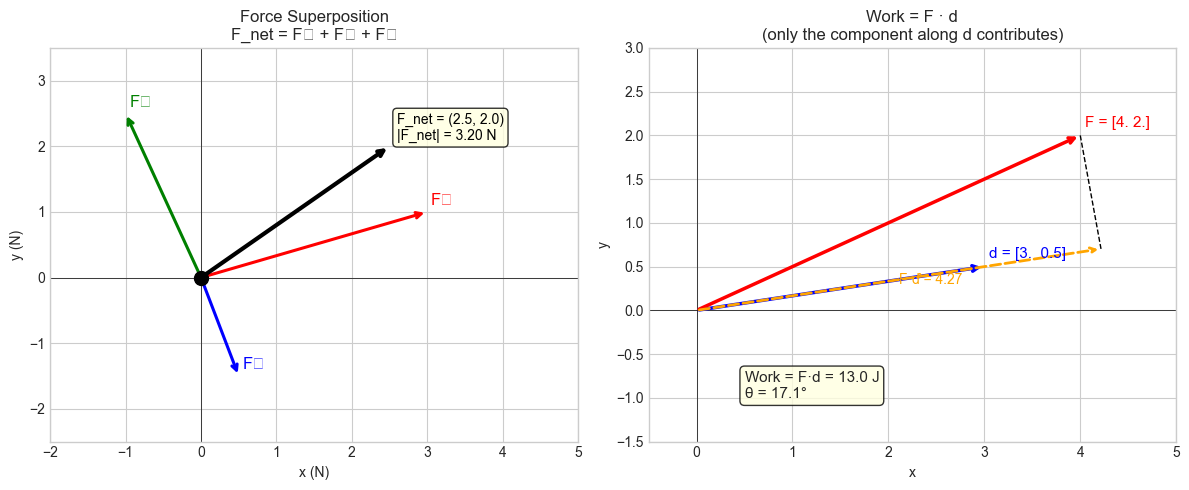

In [1]:
# --- Visualization: Force superposition and work ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel 1: Force superposition ---
ax = axes[0]
F1 = np.array([3.0, 1.0])   # Force 1
F2 = np.array([-1.0, 2.5])  # Force 2
F3 = np.array([0.5, -1.5])  # Force 3
F_net = F1 + F2 + F3

origin = np.array([0., 0.])
forces = [(F1,'red','F₁'), (F2,'green','F₂'), (F3,'blue','F₃')]
for F, c, label in forces:
    ax.annotate('', xy=F, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=c, lw=2.2))
    ax.text(F[0]+0.05, F[1]+0.1, label, fontsize=12, color=c)

ax.annotate('', xy=F_net, xytext=origin,
            arrowprops=dict(arrowstyle='->', color='black', lw=3))
ax.text(F_net[0]+0.1, F_net[1]+0.1,
        f'F_net = ({F_net[0]:.1f}, {F_net[1]:.1f})\n|F_net| = {np.linalg.norm(F_net):.2f} N',
        fontsize=10, color='black',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.plot(0, 0, 'ko', markersize=10, zorder=5)
ax.set_xlim(-2, 5); ax.set_ylim(-2.5, 3.5)
ax.set_xlabel('x (N)'); ax.set_ylabel('y (N)')
ax.set_title('Force Superposition\nF_net = F₁ + F₂ + F₃')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

# --- Panel 2: Work = dot product ---
ax2 = axes[1]
F = np.array([4.0, 2.0])   # force vector
d = np.array([3.0, 0.5])   # displacement vector

work = F @ d
theta = np.degrees(np.arccos(F@d / (np.linalg.norm(F)*np.linalg.norm(d))))

# Project F onto d
d_unit = d / np.linalg.norm(d)
F_proj = (F @ d_unit) * d_unit
F_perp = F - F_proj

ax2.annotate('', xy=d, xytext=origin, arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax2.annotate('', xy=F, xytext=origin, arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax2.annotate('', xy=F_proj, xytext=origin,
             arrowprops=dict(arrowstyle='->', color='orange', lw=2, linestyle='dashed'))
ax2.plot([F[0], F_proj[0]], [F[1], F_proj[1]], 'k--', lw=1)

ax2.text(d[0]+0.05, d[1]+0.1, f'd = {d}', fontsize=11, color='blue')
ax2.text(F[0]+0.05, F[1]+0.1, f'F = {F}', fontsize=11, color='red')
ax2.text(F_proj[0]/2, F_proj[1]-0.4, f'F·d̂ = {np.linalg.norm(F_proj):.2f}', fontsize=10, color='orange')
ax2.text(0.5, -1.0,
         f'Work = F·d = {work:.1f} J\nθ = {theta:.1f}°',
         fontsize=11, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax2.set_xlim(-0.5, 5); ax2.set_ylim(-1.5, 3)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Work = F · d\n(only the component along d contributes)')
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Newton's Second Law:**
```
F_net = m · a
```
where **F_net**, **a** ∈ ℝ³. This is a vector equation — it holds component-wise.

**Superposition of forces:**
```
F_net = F₁ + F₂ + ... + Fₙ   (vector addition)
```

**Work done by force F over displacement d:**
```
W = F · d = |F| |d| cos θ
```
Work is a scalar (energy). Only the component of F along d contributes. *(Dot product, introduced in ch131.)*

**Torque:**
```
τ = r × F
|τ| = |r| |F| sin θ
```
where **r** is the position vector from the pivot to the point of force application. Torque is a vector; its direction (given by the right-hand rule) is the axis of rotation. *(Cross product, introduced in ch136.)*

**Kinematic equations (Euler integration):**
```
a(t) = F_net(t) / m
v(t+Δt) = v(t) + a(t)·Δt
x(t+Δt) = x(t) + v(t)·Δt
```
Each step is a scalar-vector multiplication and vector addition.

**Power:**
```
P = F · v   (dot product of force and velocity)
```

---

## 5. Python Implementation

In [2]:
# --- Implementation: Newtonian particle simulator ---

import numpy as np


class Particle:
    """
    A Newtonian point mass in 2D.
    State: position x (m), velocity v (m/s)
    """

    def __init__(self, mass, position, velocity):
        """
        Args:
            mass: float (kg)
            position: array-like, shape (2,)  — initial position in meters
            velocity: array-like, shape (2,)  — initial velocity in m/s
        """
        self.mass = float(mass)
        self.x = np.array(position, dtype=float)
        self.v = np.array(velocity, dtype=float)
        self.history_x = [self.x.copy()]
        self.history_v = [self.v.copy()]

    def apply_forces(self, forces, dt):
        """
        Advance the particle by one Euler step under the given forces.

        Args:
            forces: list of np.ndarray shape (2,) — list of force vectors (N)
            dt: float — timestep (s)
        """
        F_net = sum(forces)                 # vector addition — superposition
        a = F_net / self.mass               # Newton: a = F/m
        self.v = self.v + a * dt            # Euler velocity update
        self.x = self.x + self.v * dt       # Euler position update
        self.history_x.append(self.x.copy())
        self.history_v.append(self.v.copy())

    def kinetic_energy(self):
        """KE = 0.5 m |v|^2 (scalar, joules)"""
        return 0.5 * self.mass * (self.v @ self.v)

    def momentum(self):
        """p = m * v (vector, kg·m/s)"""
        return self.mass * self.v


def work_done(force, displacement):
    """W = F · d  (joules)"""
    return float(np.dot(force, displacement))


def torque(r, F):
    """τ = r × F (3D cross product, N·m)"""
    r3 = np.array([r[0], r[1], 0.], dtype=float)
    F3 = np.array([F[0], F[1], 0.], dtype=float)
    return np.cross(r3, F3)  # returns [0, 0, τ_z]


# --- Simulation: projectile under gravity + wind ---
MASS = 1.0        # kg
G = -9.81         # m/s^2
DT = 0.05         # seconds
N_STEPS = 120

gravity = np.array([0., MASS * G])         # weight force (downward)
wind    = np.array([0.5, 0.])              # constant horizontal wind

p = Particle(mass=MASS,
             position=[0., 0.],
             velocity=[8., 12.])  # initial launch velocity

for _ in range(N_STEPS):
    if p.x[1] < 0 and len(p.history_x) > 2:
        break
    p.apply_forces([gravity, wind], DT)

traj = np.array(p.history_x)
vels = np.array(p.history_v)

print(f"Trajectory points: {len(traj)}")
print(f"Max height: {traj[:,1].max():.2f} m  at x={traj[traj[:,1].argmax(),0]:.2f} m")
print(f"Final KE: {p.kinetic_energy():.2f} J")
print(f"Work by wind over full path: {work_done(wind, traj[-1]-traj[0]):.2f} J")

Trajectory points: 49
Max height: 7.04 m  at x=9.98 m
Final KE: 108.95 J
Work by wind over full path: 10.34 J


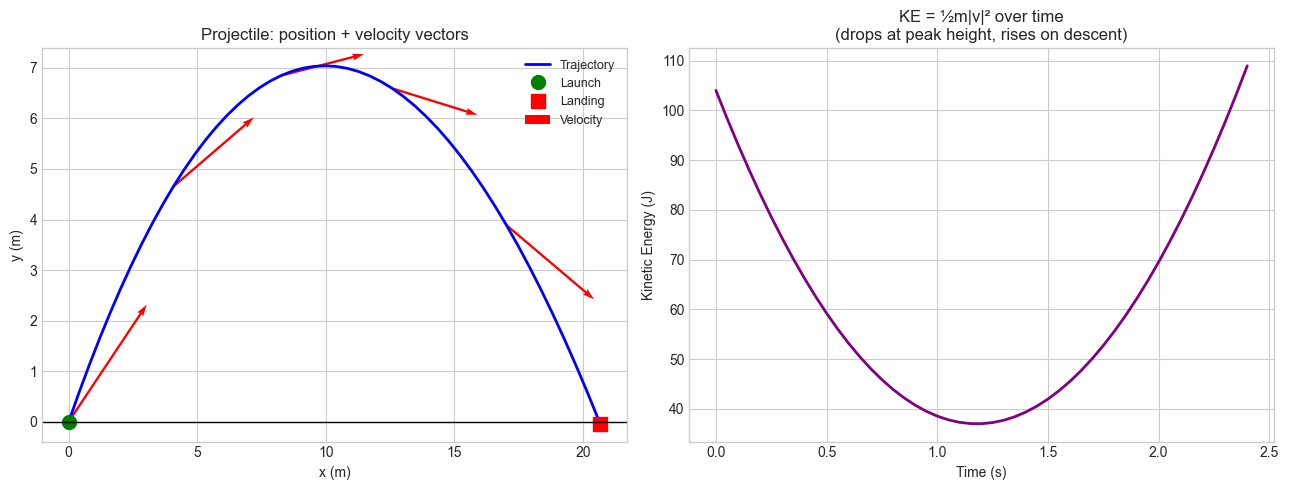

In [3]:
# --- Visualize trajectory + velocity vectors ---

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Trajectory
ax1.plot(traj[:,0], traj[:,1], 'b-', lw=2, label='Trajectory')
ax1.plot(traj[0,0], traj[0,1], 'go', markersize=10, label='Launch')
ax1.plot(traj[-1,0], traj[-1,1], 'rs', markersize=10, label='Landing')
# Velocity vectors at every 10th step
skip = 10
ax1.quiver(traj[::skip,0], traj[::skip,1],
           vels[::skip,0], vels[::skip,1],
           color='red', scale=60, width=0.004, label='Velocity')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')
ax1.set_title('Projectile: position + velocity vectors')
ax1.legend(fontsize=9)
ax1.axhline(0, color='k', lw=1)

# Kinetic energy over time
ke = [0.5 * MASS * np.dot(v,v) for v in vels]
t_vals = np.arange(len(ke)) * DT
ax2.plot(t_vals, ke, 'purple', lw=2)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Kinetic Energy (J)')
ax2.set_title('KE = ½m|v|² over time\n(drops at peak height, rises on descent)')

plt.tight_layout()
plt.show()

---

## 6. Experiments

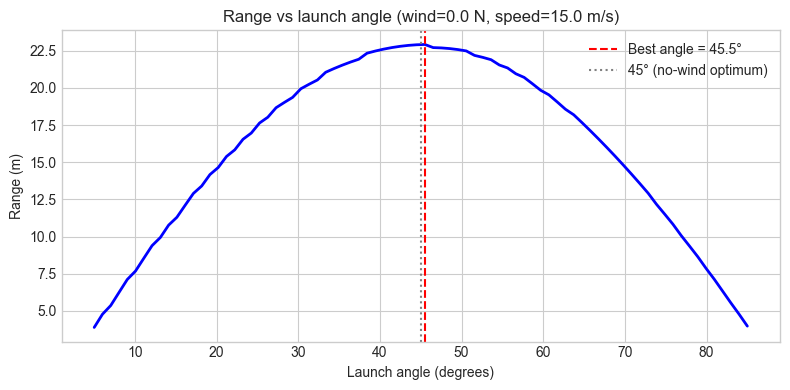

Optimal angle: 45.5° (max range: 22.92 m)


In [4]:
# --- Experiment 1: Optimal launch angle ---
# Hypothesis: Maximum range is achieved at 45° (no air resistance).
# With wind, the optimal angle shifts.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

SPEED = 15.0    # launch speed (m/s)  <-- modify
WIND_X = 0.0    # horizontal wind force (N)  <-- try 2.0

angles = np.linspace(5, 85, 80)
ranges = []

for deg in angles:
    theta = np.radians(deg)
    p = Particle(1.0, [0.,0.], [SPEED*np.cos(theta), SPEED*np.sin(theta)])
    for _ in range(2000):
        if p.x[1] < 0 and len(p.history_x) > 5:
            break
        p.apply_forces([np.array([WIND_X, -9.81]), ], 0.02)
    ranges.append(p.x[0])

best_angle = angles[np.argmax(ranges)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles, ranges, 'b-', lw=2)
ax.axvline(best_angle, color='red', linestyle='--', label=f'Best angle = {best_angle:.1f}°')
ax.axvline(45, color='gray', linestyle=':', label='45° (no-wind optimum)')
ax.set_xlabel('Launch angle (degrees)')
ax.set_ylabel('Range (m)')
ax.set_title(f'Range vs launch angle (wind={WIND_X} N, speed={SPEED} m/s)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Optimal angle: {best_angle:.1f}° (max range: {max(ranges):.2f} m)")

In [5]:
# --- Experiment 2: Work done by a force along a curved path ---
# Hypothesis: Work = F · total displacement (for constant F),
# regardless of the path taken.

import numpy as np

F = np.array([3.0, 1.5])   # constant force  <-- modify

# Path 1: straight line from A to B
A = np.array([0., 0.])
B = np.array([4., 2.])
d_straight = B - A
W_straight = F @ d_straight

# Path 2: via intermediate point C
C = np.array([1., 3.])
W_via_C = F @ (C - A) + F @ (B - C)

# Path 3: many random waypoints
rng = np.random.default_rng(42)
waypoints = np.vstack([A, rng.uniform(0,4,(8,2)), B])
W_random = sum(F @ (waypoints[i+1] - waypoints[i]) for i in range(len(waypoints)-1))

print("Work done by constant force F = (3, 1.5) from A=(0,0) to B=(4,2):")
print(f"  Straight path:      W = {W_straight:.4f} J")
print(f"  Via point C:        W = {W_via_C:.4f} J")
print(f"  Random waypoints:   W = {W_random:.4f} J")
print()
print("All equal — constant force is a conservative field.")
print("Work depends only on start and end points, not the path.")

Work done by constant force F = (3, 1.5) from A=(0,0) to B=(4,2):
  Straight path:      W = 15.0000 J
  Via point C:        W = 15.0000 J
  Random waypoints:   W = 15.0000 J

All equal — constant force is a conservative field.
Work depends only on start and end points, not the path.


---

## 7. Exercises

**Easy 1.** Three forces act on an object: **F₁** = (2, 3), **F₂** = (−1, 4), **F₃** = (0, −5). Find the net force and its magnitude. If the object has mass 2 kg, what is its acceleration vector?

**Easy 2.** Compute the work done by force **F** = (5, 2, −1) N over displacement **d** = (3, 0, 4) m. Is the force doing positive or negative work along the z-axis component?

**Medium 1.** Simulate a particle starting at (0, 5) m with velocity (2, 0) m/s under gravity only (no wind). Plot the trajectory. Compare with the analytic solution x(t) = x₀ + v₀t + ½at².

**Medium 2.** A wrench of length **r** = (0.3, 0, 0) m applies force **F** = (0, 50, 0) N to a bolt. Compute the torque vector. What is its magnitude (turning force in N·m)? Which direction does the bolt turn?

**Hard.** Implement a 2D two-body gravity simulation: two particles attract each other with force F = G·m₁·m₂/|r|² directed along the line connecting them. Simulate for 500 steps and plot both trajectories. Verify conservation of total momentum (p₁ + p₂ = const).

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Bouncing Ball Simulator ---
#
# Simulate a ball under gravity that bounces off walls.
# Track energy to see how numerical integration loses it over time.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

MASS = 1.0
DT = 0.03
N_STEPS = 600
RESTITUTION = 0.85   # energy kept per bounce  <-- try 1.0 (elastic), 0.5
BOX = np.array([[-5., 5.], [0., 8.]])  # [[xmin,xmax],[ymin,ymax]]

x = np.array([0., 5.0])
v = np.array([3.5, 4.0])
gravity = np.array([0., -9.81 * MASS])

traj = [x.copy()]
energies = [0.5*MASS*(v@v) + MASS*9.81*x[1]]
bounce_count = 0

for _ in range(N_STEPS):
    a = gravity / MASS
    v = v + a * DT
    x = x + v * DT

    # Boundary collisions
    for dim in range(2):
        if x[dim] < BOX[dim, 0]:
            x[dim] = BOX[dim, 0]
            v[dim] = abs(v[dim]) * RESTITUTION
            bounce_count += 1
        elif x[dim] > BOX[dim, 1]:
            x[dim] = BOX[dim, 1]
            v[dim] = -abs(v[dim]) * RESTITUTION
            bounce_count += 1

    traj.append(x.copy())
    energies.append(0.5*MASS*(v@v) + MASS*9.81*x[1])

traj = np.array(traj)
energies = np.array(energies)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Trajectory colored by speed
speeds = np.linalg.norm(np.diff(traj, axis=0) / DT, axis=1)
sc = ax1.scatter(traj[:-1,0], traj[:-1,1], c=speeds, cmap='hot', s=4)
plt.colorbar(sc, ax=ax1, label='Speed (m/s)')
rect = plt.Rectangle((BOX[0,0], BOX[1,0]),
                       BOX[0,1]-BOX[0,0], BOX[1,1]-BOX[1,0],
                       fill=False, edgecolor='blue', lw=2)
ax1.add_patch(rect)
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')
ax1.set_title(f'Bouncing ball trajectory\n{bounce_count} bounces, restitution={RESTITUTION}')

# Energy over time
ax2.plot(np.arange(len(energies))*DT, energies, 'purple', lw=1.5)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Total energy (J)')
ax2.set_title(f'Energy decay: {energies[0]:.2f} → {energies[-1]:.2f} J\n'
               f'(restitution={RESTITUTION} → energy loss per bounce)')

plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What was covered:**
- Physical quantities with magnitude and direction are vectors; they obey the same algebra as abstract vectors.
- Force superposition = vector addition. Newton's second law is a vector equation.
- Work = dot product of force and displacement (scalar — the component along motion).
- Torque = cross product of position and force (vector — rotation axis and magnitude).
- Euler integration is a per-timestep scalar multiplication and vector addition.

**Backward connection:** The dot product *(introduced in ch131)* and cross product *(introduced in ch136)* find their most tangible physical meaning here. The projection formula *(introduced in ch134)* gives the exact component of force that does work.

**Forward connections:**
- In ch149 (Project: Particle Simulation), these mechanics are extended to multi-particle systems with interaction forces.
- This will reappear in ch213 (Gradient Intuition): gradients are force-like vectors pointing in the direction of steepest increase — gradient descent is anti-gravity for a loss landscape.
- In ch150 (Project: Vector-Based Game Physics), the full rigid-body simulation pipeline uses everything in this chapter simultaneously.